In [1]:
import argparse
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch
import datetime
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from data_preprocessing import load_data, preprocess_data_MLP, preprocess_data_1D_CNN
import yaml
import torch.nn as nn
import torch.nn.functional as F

In [10]:
def plot_results_overlay_from_csv(
    csv_path_0,
    csv_path_1,
    save_path=None,
    title='Prediction vs Actual (Overlay)',x_lim=None, y_lim=None
):
    # ---- Load data ----
    y_test_0, y_pred_0 = load_pred_csv(csv_path_0)
    y_test_1, y_pred_1 = load_pred_csv(csv_path_1)

    # ---- Plotting ----
    plt.figure(figsize=(10, 5))

    # Target 0
    plt.scatter(
        y_test_0, y_pred_0,
        alpha=0.5, label='Target 0', s=18
    )

    # Target 1
    plt.scatter(
        y_test_1, y_pred_1,
        alpha=0.5, label='Target 1', s=18
    )

    plt.xlabel('Actual Values (True Values)')
    plt.ylabel('Predicted Values (Predictions)')
    plt.title(title)
    plt.grid()
    if x_lim:
        plt.xlim(x_lim)
    if y_lim:
        plt.ylim(y_lim)


    # Diagonal line based on both datasets
    combined_min = min(np.min(y_test_0), np.min(y_pred_0),
                       np.min(y_test_1), np.min(y_pred_1))
    combined_max = max(np.max(y_test_0), np.max(y_pred_0),
                       np.max(y_test_1), np.max(y_pred_1))

    plt.plot(
        [combined_min, combined_max],
        [combined_min, combined_max],
        'r--', label='y = x'
    )

    plt.legend()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'-------> Saved overlay plot to {save_path}')
        plt.close()
    else:
        plt.show()

def load_pred_csv(csv_path):
    """
    CSV에서 y_test, y_pred를 불러오는 함수
    CSV는 반드시 y_test, y_pred 컬럼을 포함해야 함.
    """
    df = pd.read_csv(csv_path)

    y_test = df['y_test'].values
    y_pred = df['y_pred'].values

    return y_test, y_pred

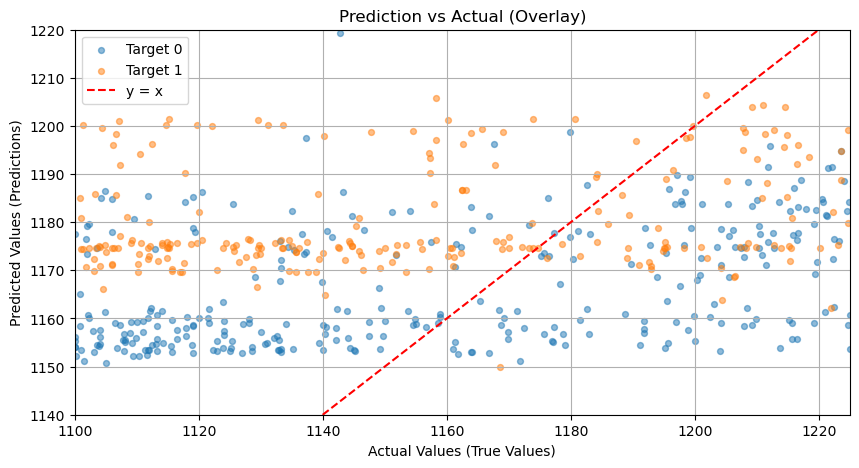

In [16]:
train_test = "7. train" 
model_type = "resnet_mlp"
time = "1203-134851"
path_0 = f"./outputs/{train_test}_pred_true_csv/{model_type}_Training_target_0_pred_true_{time}.csv"
path_1 = f"./outputs/{train_test}_pred_true_csv/{model_type}_Training_target_1_pred_true_{time}.csv"
x_lim = [1100,1225]
y_lim = [1140,1220]


plot_results_overlay_from_csv(
    path_0,
    path_1,
    x_lim= x_lim,
    y_lim= y_lim
)

In [3]:
X_train, X_test, y_train, y_test, _, _, _, _, _ = preprocess_data_MLP(
    examples, labels, scale_labels=False
)

print("\n=== Processed X_train ===")
print(X_train)
print("\nshape:", X_train.shape)   # should be (n_samples, 5)

# DataLoader
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_ds, batch_size=2, shuffle=False)

print("\n=== Checking DataLoader batches ===")
for batch_idx, (data, target) in enumerate(train_loader):
    print(f"\nBatch {batch_idx}:")
    print("data:\n", data)
    print("target:\n", target)

--------------------------------------step 2: Preprocess Data--------------------------------------
scale_labels: False
hiii

=== Processed X_train ===
[[ 10.  20.  30.  40.  50.]
 [100. 200. 300. 400. 500.]]

shape: (2, 5)

=== Checking DataLoader batches ===

Batch 0:
data:
 tensor([[ 10.,  20.,  30.,  40.,  50.],
        [100., 200., 300., 400., 500.]])
target:
 tensor([[1.],
        [2.]])


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_loss_from_csv(
    csv_path,
    save_path=None,
    title='Training & Validation Loss',
    y_lim=None
):
    # ---- Load CSV ----
    df = pd.read_csv(csv_path)

    # ---- Extract loss curves ----
    train_loss = df['train_loss']
    val_loss = df['val_loss'] if 'val_loss' in df.columns else None

    # ---- Plot ----
    plt.figure(figsize=(10, 5))

    plt.plot(train_loss, label='Train Loss', linewidth=2)
    
    if val_loss is not None:
        plt.plot(val_loss, label='Validation Loss', linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.grid()

    if y_lim:
        plt.ylim(y_lim)

    plt.legend()

    # ---- Save or Show ----
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'-------> Saved loss plot to {save_path}')
        plt.close()
    else:
        plt.show()


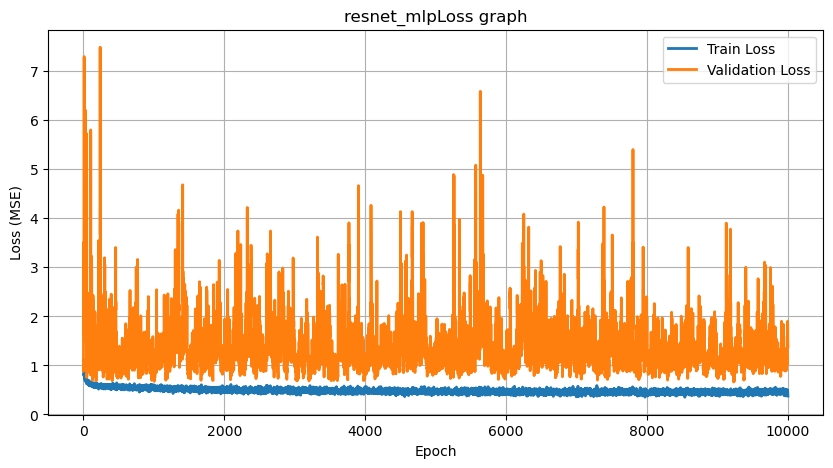

-------> Saved loss plot to ./outputs/9. Important figures/Resnet_DNN/resnet_mlp_losses_1204-163647.png


In [33]:
train_test = "5. loss_csv" 
model_type = "resnet_mlp"
time = "1204-163647"
path_0 = f"./outputs/{train_test}/{model_type}_losses_{time}.csv"
# path_1 = f"./outputs/{train_test}_pred_true_csv/{model_type}_Training_target_1_pred_true_{time}.csv"
# x_lim = [1100,1225]
y_lim = [0,10]

save_path = f'./outputs/9. Important figures/Resnet_DNN/{model_type}_losses_{time}.png'
plot_loss_from_csv(path_0, save_path=None, title=f'{model_type}Loss graph')#,y_lim=y_lim)
plot_loss_from_csv(path_0, save_path=save_path, title=f'{model_type}Loss graph')#, y_lim=y_lim)

In [ ]:
lstm_losses_1204-170838